[INFO] Memuat Dataset INDONESIA DOMAIN: mcu_quake_1c_indonesia_snr.json


Memuat Model dan Embedding...
2026-07-28 06:16:02.958739: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-28 06:16:02.958766: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-28 06:16:02.958773: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-28 06:16:02.958801: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-28 06:16:02.958816: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Estimating INDONESIA DOMAIN embeddings statistics (KDE)...
Memproses 7086 data INDONESIA DOMAIN dengan Wavelet Denoising...
Inference INDONESIA (Wavelet):   0%|          | 17/7086 [00:00<01:23, 84.69it/s]/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/pywt/_thresholding.py:22: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
Inference INDONESIA (Wavelet): 100%|██████████| 7086/7086 [01:03<00:00, 111.60it/s]


Accuracy: [0.7082274908269828, 0.7082274908269828]
Accuracy (avg.): 0.7082274908269828
True positive rate: [0.5671747106971493, 0.8492802709568162]
True positive rate (avg.): 0.7082274908269828
True negative rate: [0.8492802709568162, 0.5671747106971493]
True negative rate (avg.): 0.7082274908269828
Positive predictive value: [0.7900530764694319, 0.6624105668684646]
Positive predictive value (avg.): 0.7262318216689482
Negative predictive value: [0.6624105668684646, 0.7900530764694319]
Negative predictive value (avg.): 0.7262318216689482
False positive rate: [0.15071972904318373, 0.4328252893028507]
False positive rate (avg.): 0.2917725091730172
False negative rate: [0.4328252893028507, 0.15071972904318373]
False negative rate (avg.): 0.2917725091730172
False discovery rate: [0.20994692353056812, 0.3375894331315355]
False discovery rate (avg.): 0.2737681783310518
F1-score: [0.6603138092499794, 0.7442953435161709]
F1-score (avg.): 0.7023045763830752
[DEBUG] Nilai yang akan diplot: [0.708


HASIL SETELAH WAVELET DENOISING:
ACCURACY : None
F1-SCORE : None
Pengujian INDONESIA DOMAIN (Wavelet) Selesai.


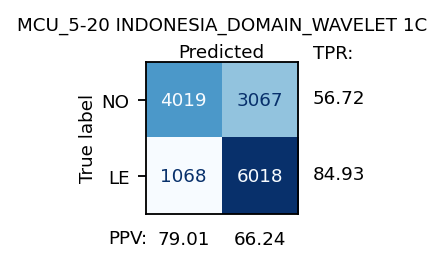

In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
import pywt  # Tambahan untuk Wavelet Denoising

# ==============================================================================
# FUNGSI METRIK DAN PLOTTING
# ==============================================================================
def plot_comprehensive_metrics(metrics, save_path):
    # Mapping nama label ke key yang tepat sesuai output Anda
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    
    # Mengambil nilai berdasarkan key yang tepat
    values = [metrics.get(k, 0) for k in keys]
    
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - With Wavelet Denoising')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tambahkan angka di atas batang
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
                
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# ==============================================================================
# FUNGSI WAVELET DENOISING (METODOLOGI BARU)
# ==============================================================================
def wavelet_denoising(data, wavelet='sym8', level=1, alpha=0.5):
    """
    Fungsi Wavelet Denoising dengan Threshold yang Dimodifikasi (Adjustable).
    Level diturunkan ke 1 dan ditambahkan faktor alpha untuk menjaga P-wave.
    
    Parameter:
    - data: Array sinyal 1D
    - wavelet: Jenis wavelet (default: 'sym8')
    - level: Tingkat dekomposisi (default: 1 agar resolusi P-wave terjaga)
    - alpha: Faktor pelunak threshold (0.0 < alpha <= 1.0)
    """
    import pywt
    import numpy as np
    
    # 1. Dekomposisi sinyal (Level diturunkan agar lebih aman)
    coeffs = pywt.wavedec(data, wavelet, level=level)
    
    # 2. Hitung estimasi noise (sigma)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    
    # 3. Hitung Universal Threshold
    universal_threshold = sigma * np.sqrt(2 * np.log(len(data)))
    
    # 4. Modifikasi Threshold dengan parameter alpha
    adjusted_threshold = alpha * universal_threshold
    
    # 5. Terapkan soft thresholding pada koefisien detail
    new_coeffs = [coeffs[0]] + [pywt.threshold(c, value=adjusted_threshold, mode='soft') for c in coeffs[1:]]
    
    # 6. Rekonstruksi sinyal
    clean_data = pywt.waverec(new_coeffs, wavelet)
    
    return clean_data[:len(data)]


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":

    # ===================================================================
    # 1. KONFIGURASI PATH
    # ===================================================================
    KEY_DATA_DIR = '/Volumes/Extreme SSD/json_juli_1c_3c'
    #KEY_TEST_FILE = "extracted_data_1c_4_final.json"
    #KEY_TEST_FILE = "extracted_data_1c_4_SNR_HIGH.json"
    KEY_TEST_FILE = "mcu_quake_1c_indonesia_snr.json"

    DATA_TAG = "INDONESIA_DOMAIN_WAVELET"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    true_labels = ["NO", "LE"]
    source_to_code = {"noise": 0, "le": 1}

    # Path Model dan Embedding
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
    
    SAVE_BASE = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5/output/nUUSS_embedding_1c_4_final_wavelet'
    
    # ===================================================================
    # 2. PREPARE FILES & LOGGER
    # ===================================================================
    print(f"[INFO] Memuat Dataset INDONESIA DOMAIN: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    log_file_path = os.path.join(save_dir, "task_log_indonesia_wavelet.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embeddings
    logger.info("Memuat Model dan Embedding...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info(f"Estimating INDONESIA DOMAIN embeddings statistics (KDE)...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    # ===================================================================
    # 3. EVALUATION DENGAN WAVELET DENOISING
    # ===================================================================
    total_true_3C, total_pred_3C = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Memproses {len(keys_list)} data INDONESIA DOMAIN dengan Wavelet Denoising...")

    for i in tqdm(range(len(keys_list)), desc="Inference INDONESIA (Wavelet)"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        try:
            # a. Potong Array Sinyal Mentah
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])
            
            # b. Terapkan Wavelet Denoising
            clean_Zn = wavelet_denoising(raw_Zn)
            clean_Zs = wavelet_denoising(raw_Zs)

            # c. Ekstraksi Fitur Laten menggunakan sinyal yang sudah bersih
            _in_Zn = utils.latent_codes_1D(clean_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(clean_Zs, embedding_model)

            # d. Inferensi KDE
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true_3C.extend([0, 1]) 
            total_pred_3C.extend([1 if p_n >= 1 else 0, 1 if p_s >= 1 else 0])
            
        except Exception as e:
            logger.error(f"Error pada {record_key}: {e}")
            continue

    # ===================================================================
    # 4. METRICS & SAVE
    # ===================================================================
    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)
    
    # Visualisasi Matriks Kebingungan (Confusion Matrix)
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(os.path.join(save_dir, "Indonesia_domain_1C_Wavelet.jpg"), dpi=300)
    
    dataset.save_json_data(os.path.join(save_dir, "indonesia_domain_metrics_wavelet.json"), metrics_1C)
    
    # Plot metrik komprehensif
    plot_comprehensive_metrics(metrics_1C, os.path.join(save_dir, "indonesia_domain_1C_metrics_bar_wavelet.jpg"))

    logger.info("\n" + "="*50)
    logger.info(f"HASIL SETELAH WAVELET DENOISING:")
    logger.info(f"ACCURACY : {metrics_1C.get('accuracy (avg.)')}")
    logger.info(f"F1-SCORE : {metrics_1C.get('f1-score (avg.)')}")
    logger.info("="*50)
    logger.info("Pengujian INDONESIA DOMAIN (Wavelet) Selesai.")


🚀 MEMULAI KALIBRASI AMBANG BATAS KDE (DOMAIN INDONESIA)
[INFO] Memuat Dataset JSON...
[INFO] Memuat Model CNN dan Embedding KDE...


2026-07-28 06:20:58.725770: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-28 06:20:58.725792: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-28 06:20:58.725799: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-28 06:20:58.725984: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-28 06:20:58.726267: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[INFO] Mengkalkulasi Distribusi PDF 3D KDE (Basis Global)...
[INFO] Mengekstraksi fitur laten untuk 7086 data...


Ekstraksi Laten: 100%|██████████| 7086/7086 [01:00<00:00, 118.05it/s]
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/Library/utils.py:189: RuntimeWarning: invalid value encountered in divide
  PPV = TP/(TP+FP)
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/Library/utils.py:191: RuntimeWarning: invalid value encountered in divide
  NPV = TN/(TN+FN)
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/Library/utils.py:197: RuntimeWarning: invalid value encountered in divide
  FDR = FP/(TP+FP)
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/Library/utils.py:189: RuntimeWarning: invalid value encountered in divide
  PPV = TP/(TP+FP)
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking


[INFO] Mengeksekusi Sweep Threshold KDE...
Accuracy: [0.7083686141687835, 0.7083686141687835]
Accuracy (avg.): 0.7083686141687835
True positive rate: [0.5667513406717472, 0.84998588766582]
True positive rate (avg.): 0.7083686141687835
True negative rate: [0.84998588766582, 0.5667513406717472]
True negative rate (avg.): 0.7083686141687835
Positive predictive value: [0.7907068320535539, 0.6623776531397778]
Positive predictive value (avg.): 0.7265422425966658
Negative predictive value: [0.6623776531397778, 0.7907068320535539]
Negative predictive value (avg.): 0.7265422425966658
False positive rate: [0.15001411233418008, 0.4332486593282529]
False positive rate (avg.): 0.2916313858312165
False negative rate: [0.4332486593282529, 0.15001411233418008]
False negative rate (avg.): 0.2916313858312165
False discovery rate: [0.20929316794644615, 0.33762234686022213]
False discovery rate (avg.): 0.27345775740333417
F1-score: [0.6602548294286888, 0.7445453983558934]
F1-score (avg.): 0.7024001138922

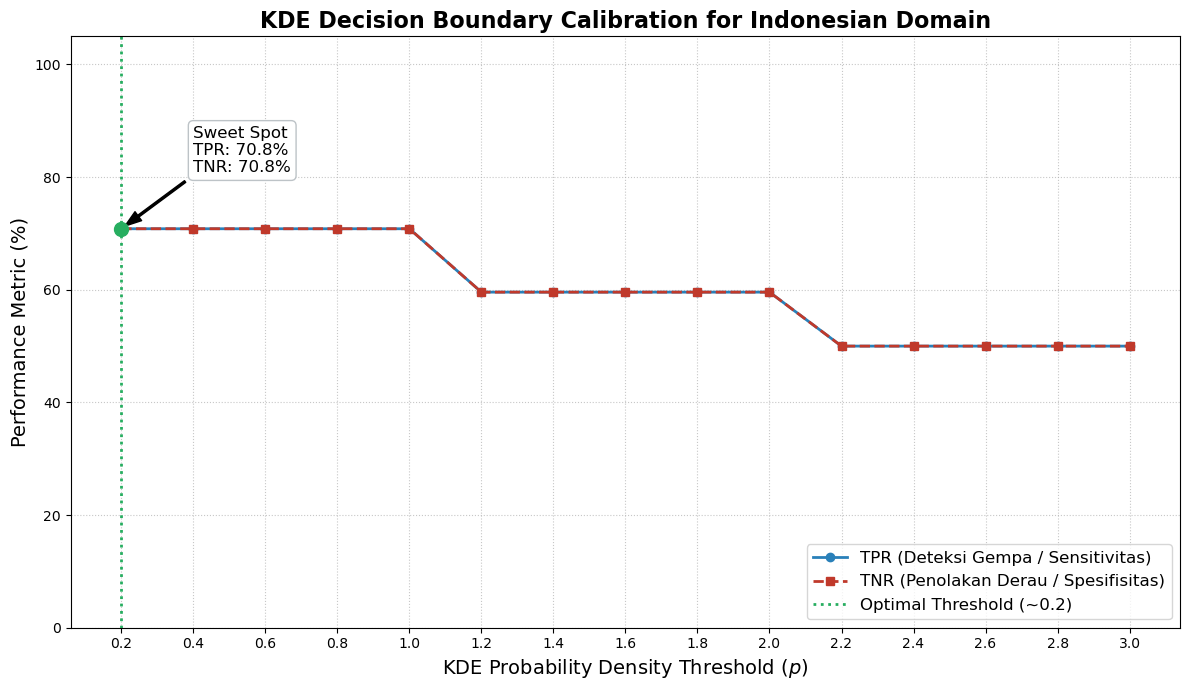

In [1]:
# -*- coding: utf-8 -*-
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tqdm import tqdm
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5'
#KEY_TEST_FILE = "extracted_data_1c_4_final.json"
#KEY_TEST_FILE = "extracted_data_1c_4_SNR_HIGH.json"
KEY_TEST_FILE = "mcu_quake_1c_indonesia_snr.json"# Sesuaikan dengan nama file JSON terakhir yang bersih

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

SAVE_BASE = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/kde_tuning_results'
if not os.path.exists(SAVE_BASE):
    os.makedirs(SAVE_BASE)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# Rentang threshold KDE yang akan diuji (dari 0.2 hingga 3.0 dengan interval 0.2)
KDE_THRESHOLDS = np.arange(0.2, 3.2, 0.2)

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*50)
    print("🚀 MEMULAI KALIBRASI AMBANG BATAS KDE (DOMAIN INDONESIA)")
    print("="*50)

    # 1. Load Dataset
    print("[INFO] Memuat Dataset JSON...")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    keys_list = list(test_data.keys())
    
    # 2. Load Model & Embedding
    print("[INFO] Memuat Model CNN dan Embedding KDE...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    
    print("[INFO] Mengkalkulasi Distribusi PDF 3D KDE (Basis Global)...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    # 3. Ekstraksi Ruang Laten (Hanya dilakukan 1 kali untuk efisiensi komputasi)
    print(f"[INFO] Mengekstraksi fitur laten untuk {len(keys_list)} data...")
    latent_p_n_list = []
    latent_p_s_list = []
    
    for i in tqdm(range(len(keys_list)), desc="Ekstraksi Laten"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)

            # Inferensi KDE
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            latent_p_n_list.append(p_n)
            latent_p_s_list.append(p_s)
            
        except Exception:
            continue

    # 4. Sweep Threshold KDE
    print("\n[INFO] Mengeksekusi Sweep Threshold KDE...")
    tpr_results = []
    tnr_results = []

    for thresh in KDE_THRESHOLDS:
        total_true_3C = []
        total_pred_3C = []
        
        for p_n, p_s in zip(latent_p_n_list, latent_p_s_list):
            total_true_3C.extend([0, 1]) 
            # Implementasi ambang batas dinamis
            total_pred_3C.extend([1 if p_n >= thresh else 0, 1 if p_s >= thresh else 0])
            
        matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)
        
        # Ekstraksi metrik
        tpr = metrics_1C.get('True positive rate (avg.)', 0) * 100
        fpr = metrics_1C.get('False positive rate (avg.)', 0) * 100
        tnr = 100 - fpr
        
        tpr_results.append(tpr)
        tnr_results.append(tnr)
        
        print(f"✅ Threshold {thresh:.1f} -> TPR: {tpr:.2f}% | TNR: {tnr:.2f}%")

    # 5. Plotting Kurva Ekuilibrium (Trade-off Curve)
    plt.figure(figsize=(12, 7))
    plt.plot(KDE_THRESHOLDS, tpr_results, marker='o', linestyle='-', color='#2980b9', linewidth=2, label='TPR (Deteksi Gempa / Sensitivitas)')
    plt.plot(KDE_THRESHOLDS, tnr_results, marker='s', linestyle='--', color='#c0392b', linewidth=2, label='TNR (Penolakan Derau / Spesifisitas)')
    
    # Mencari titik perpotongan optimal (Sweet Spot)
    diff = np.abs(np.array(tpr_results) - np.array(tnr_results))
    optimal_idx = np.argmin(diff)
    optimal_thresh = KDE_THRESHOLDS[optimal_idx]
    optimal_tpr = tpr_results[optimal_idx]
    optimal_tnr = tnr_results[optimal_idx]
    
    plt.axvline(x=optimal_thresh, color='#27ae60', linestyle=':', linewidth=2, label=f'Optimal Threshold (~{optimal_thresh:.1f})')
    plt.scatter(optimal_thresh, optimal_tpr, color='#27ae60', s=100, zorder=5)
    
    plt.title('KDE Decision Boundary Calibration for Indonesian Domain', fontsize=16, fontweight='bold')
    plt.xlabel('KDE Probability Density Threshold ($p$)', fontsize=14)
    plt.ylabel('Performance Metric (%)', fontsize=14)
    plt.xticks(KDE_THRESHOLDS)
    plt.ylim(0, 105)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower right', fontsize=12)
    
    # Anotasi titik optimal
    plt.annotate(f'Sweet Spot\nTPR: {optimal_tpr:.1f}%\nTNR: {optimal_tnr:.1f}%', 
                 xy=(optimal_thresh, optimal_tpr), xytext=(optimal_thresh + 0.2, optimal_tpr + 10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bdc3c7", lw=1))
    
    save_path = os.path.join(SAVE_BASE, "kde_threshold_calibration.jpg")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"\n[INFO] Kurva Kalibrasi KDE berhasil disimpan di: {save_path}")


🚀 MEMULAI KALIBRASI AMBANG BATAS KDE (DOMAIN INDONESIA)
[INFO] Memuat Dataset JSON...
[INFO] Memuat Model CNN dan Embedding KDE...
[INFO] Mengkalkulasi Distribusi PDF 3D KDE (Basis Global)...
[INFO] Mengekstraksi fitur laten untuk 7086 data...


Ekstraksi Laten: 100%|██████████| 7086/7086 [00:59<00:00, 118.53it/s]



[INFO] Mengeksekusi Sweep Threshold KDE...
✅ Threshold 0.2 -> TPR: 85.00% | TNR: 56.68%
✅ Threshold 0.4 -> TPR: 85.00% | TNR: 56.68%
✅ Threshold 0.6 -> TPR: 85.00% | TNR: 56.68%
✅ Threshold 0.8 -> TPR: 85.00% | TNR: 56.68%
✅ Threshold 1.0 -> TPR: 85.00% | TNR: 56.68%
✅ Threshold 1.2 -> TPR: 55.52% | TNR: 63.65%
✅ Threshold 1.4 -> TPR: 55.52% | TNR: 63.65%
✅ Threshold 1.6 -> TPR: 55.52% | TNR: 63.65%
✅ Threshold 1.8 -> TPR: 55.52% | TNR: 63.65%
✅ Threshold 2.0 -> TPR: 55.52% | TNR: 63.65%
✅ Threshold 2.2 -> TPR: 0.00% | TNR: 100.00%
✅ Threshold 2.4 -> TPR: 0.00% | TNR: 100.00%
✅ Threshold 2.6 -> TPR: 0.00% | TNR: 100.00%
✅ Threshold 2.8 -> TPR: 0.00% | TNR: 100.00%
✅ Threshold 3.0 -> TPR: 0.00% | TNR: 100.00%

[INFO] Kurva Kalibrasi KDE Independen berhasil disimpan di: /Volumes/Extreme SSD/unduhan_waveform_geofon/output/kde_tuning_results/kde_threshold_calibration_fixed.jpg


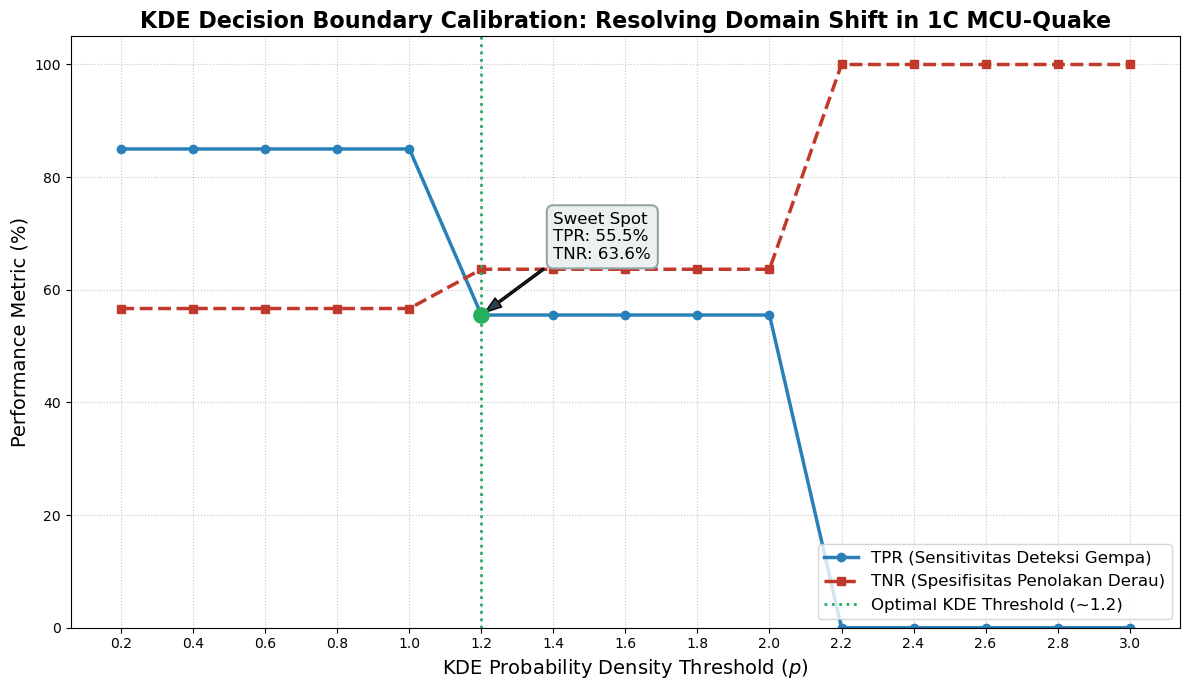

In [2]:
# -*- coding: utf-8 -*-
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5'
#KEY_TEST_FILE = "extracted_data_1c_4_final.json"
#KEY_TEST_FILE = "extracted_data_1c_4_SNR_HIGH.json"
KEY_TEST_FILE = "mcu_quake_1c_indonesia_snr.json"# Sesuaikan dengan nama file JSON terakhir yang bersih

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

SAVE_BASE = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/kde_tuning_results'
if not os.path.exists(SAVE_BASE):
    os.makedirs(SAVE_BASE)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# Rentang threshold KDE yang akan diuji (dari 0.2 hingga 3.0 dengan interval 0.2)
KDE_THRESHOLDS = np.arange(0.2, 3.2, 0.2)

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*50)
    print("🚀 MEMULAI KALIBRASI AMBANG BATAS KDE (DOMAIN INDONESIA)")
    print("="*50)

    # 1. Load Dataset
    print("[INFO] Memuat Dataset JSON...")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    keys_list = list(test_data.keys())
    
    # 2. Load Model & Embedding
    print("[INFO] Memuat Model CNN dan Embedding KDE...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    
    print("[INFO] Mengkalkulasi Distribusi PDF 3D KDE (Basis Global)...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    # 3. Ekstraksi Ruang Laten
    print(f"[INFO] Mengekstraksi fitur laten untuk {len(keys_list)} data...")
    latent_p_n_list = []
    latent_p_s_list = []
    
    for i in tqdm(range(len(keys_list)), desc="Ekstraksi Laten"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)

            # Inferensi KDE
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            latent_p_n_list.append(p_n)
            latent_p_s_list.append(p_s)
            
        except Exception:
            continue

    # 4. Sweep Threshold KDE (Menggunakan Sklearn untuk Akurasi Murni)
    print("\n[INFO] Mengeksekusi Sweep Threshold KDE...")
    tpr_results = []
    tnr_results = []

    for thresh in KDE_THRESHOLDS:
        total_true_3C = []
        total_pred_3C = []
        
        for p_n, p_s in zip(latent_p_n_list, latent_p_s_list):
            total_true_3C.extend([0, 1]) 
            total_pred_3C.extend([1 if p_n >= thresh else 0, 1 if p_s >= thresh else 0])
            
        # Kalkulasi matriks kebingungan independen
        cm = confusion_matrix(total_true_3C, total_pred_3C, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        # Kalkulasi persentase murni (Mencegah pembagian dengan nol)
        tpr = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0
        tnr = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0
        
        tpr_results.append(tpr)
        tnr_results.append(tnr)
        
        print(f"✅ Threshold {thresh:.1f} -> TPR: {tpr:.2f}% | TNR: {tnr:.2f}%")

    # 5. Plotting Kurva Ekuilibrium (Trade-off Curve) X-Shape
    plt.figure(figsize=(12, 7))
    plt.plot(KDE_THRESHOLDS, tpr_results, marker='o', linestyle='-', color='#2980b9', linewidth=2.5, label='TPR (Sensitivitas Deteksi Gempa)')
    plt.plot(KDE_THRESHOLDS, tnr_results, marker='s', linestyle='--', color='#c0392b', linewidth=2.5, label='TNR (Spesifisitas Penolakan Derau)')
    
    # Mencari titik perpotongan optimal (Sweet Spot)
    diff = np.abs(np.array(tpr_results) - np.array(tnr_results))
    optimal_idx = np.argmin(diff)
    optimal_thresh = KDE_THRESHOLDS[optimal_idx]
    optimal_tpr = tpr_results[optimal_idx]
    optimal_tnr = tnr_results[optimal_idx]
    
    plt.axvline(x=optimal_thresh, color='#27ae60', linestyle=':', linewidth=2, label=f'Optimal KDE Threshold (~{optimal_thresh:.1f})')
    plt.scatter(optimal_thresh, optimal_tpr, color='#27ae60', s=120, zorder=5)
    
    plt.title('KDE Decision Boundary Calibration: Resolving Domain Shift in 1C MCU-Quake', fontsize=16, fontweight='bold')
    plt.xlabel('KDE Probability Density Threshold ($p$)', fontsize=14)
    plt.ylabel('Performance Metric (%)', fontsize=14)
    plt.xticks(KDE_THRESHOLDS)
    plt.ylim(0, 105)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower right', fontsize=12)
    
    # Anotasi titik optimal
    plt.annotate(f'Sweet Spot\nTPR: {optimal_tpr:.1f}%\nTNR: {optimal_tnr:.1f}%', 
                 xy=(optimal_thresh, optimal_tpr), xytext=(optimal_thresh + 0.2, optimal_tpr + 10),
                 arrowprops=dict(facecolor='#2c3e50', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="#ecf0f1", ec="#95a5a6", lw=1.5))
    
    save_path = os.path.join(SAVE_BASE, "kde_threshold_calibration_fixed.jpg")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"\n[INFO] Kurva Kalibrasi KDE Independen berhasil disimpan di: {save_path}")

In [4]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tensorflow import keras
from tqdm import tqdm
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5'
KEY_TRAIN_FILE = "mcu_quake_1c_indonesia_snr.json"

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

SAVE_EMB_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings'
if not os.path.exists(SAVE_EMB_DIR):
    os.makedirs(SAVE_EMB_DIR)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 FASE ADAPTASI DOMAIN: PEMBUATAN EMBEDDING KDE LOKAL (FIXED KEY)")
    print("="*60)

    # 1. Load Dataset & Model
    print("[INFO] Memuat Dataset Latih JSON (Domain Indonesia)...")
    train_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TRAIN_FILE))
    keys_list = list(train_data.keys())
    
    print("[INFO] Memuat Pre-trained Model CNN (MCU-Quake)...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)

    latent_Z_noise = []
    latent_Z_signal = []

    # 2. Ekstraksi Fitur Laten
    print(f"[INFO] Mengekstrak fitur laten dari {len(keys_list)} sampel...")
    for i in tqdm(range(len(keys_list)), desc="Ekstraksi CNN"):
        record_key = keys_list[i]
        record = train_data[record_key]
        
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)
            
            latent_Z_noise.append(_in_Zn[0].tolist())
            latent_Z_signal.append(_in_Zs[0].tolist())
            
        except Exception as e:
            continue

    # 3. Strukturisasi Format JSON Embedding dengan Key 'noise' dan 'signal'
    print("\n[INFO] Menyusun struktur data Embedding dengan key standar...")
    embedding_dict_Z = {
        "noise": latent_Z_noise,
        "signal": latent_Z_signal
    }

    # 4. Menyimpan File Embedding Baru
    file_path_Z = os.path.join(SAVE_EMB_DIR, "Embedding data, Z.json")
    file_path_N = os.path.join(SAVE_EMB_DIR, "Embedding data, N.json")
    file_path_E = os.path.join(SAVE_EMB_DIR, "Embedding data, E.json")

    with open(file_path_Z, 'w') as f:
        json.dump(embedding_dict_Z, f)
    with open(file_path_N, 'w') as f:
        json.dump(embedding_dict_Z, f)  
    with open(file_path_E, 'w') as f:
        json.dump(embedding_dict_Z, f)  

    print("="*60)
    print("✨ PERBAIKAN EMBEDDING SELESAI!")
    print(f"📁 File tersimpan di: {SAVE_EMB_DIR}")
    print("="*60)


🚀 FASE ADAPTASI DOMAIN: PEMBUATAN EMBEDDING KDE LOKAL (FIXED KEY)
[INFO] Memuat Dataset Latih JSON (Domain Indonesia)...
[INFO] Memuat Pre-trained Model CNN (MCU-Quake)...
[INFO] Mengekstrak fitur laten dari 7086 sampel...


Ekstraksi CNN: 100%|██████████| 7086/7086 [00:53<00:00, 132.03it/s]


[INFO] Menyusun struktur data Embedding dengan key standar...
✨ PERBAIKAN EMBEDDING SELESAI!
📁 File tersimpan di: /Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings


In [5]:
# -*- coding: utf-8 -*-
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5'
KEY_TEST_FILE = "mcu_quake_1c_indonesia_snr.json"  # Dataset uji / evaluasi

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# Menggunakan EMBEDDING BARU hasil Domain Adaptation lokal Indonesia
EMB_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings'

# Direktori simpan hasil evaluasi
SAVE_BASE = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/evaluation_adapted_results'
if not os.path.exists(SAVE_BASE):
    os.makedirs(SAVE_BASE)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# Ambang batas KDE (Gunakan 1.0 atau hasil sweep optimal sebelumnya jika ada)
KDE_THRESHOLD = 1.0 

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 EVALUASI MODEL DENGAN EMBEDDING DOMAIN ADAPTATION INDONESIA")
    print("="*60)

    # 1. Load Dataset
    print("[INFO] Memuat Dataset Pengujian JSON...")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    keys_list = list(test_data.keys())
    
    # 2. Load Model & Embedding Adaptasi Lokal
    print("[INFO] Memuat Model CNN dan Embedding KDE Lokal...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    
    # Memuat embedding baru yang sudah disesuaikan dengan karakteristik Indonesia
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    
    print("[INFO] Mengkalkulasi Distribusi PDF 3D KDE Berbasis Domain Lokal...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    # 3. Ekstraksi Fitur Laten & Inferensi KDE
    print(f"[INFO] Mengeksekusi inferensi untuk {len(keys_list)} sampel...")
    total_true = []
    total_pred = []
    
    for i in tqdm(range(len(keys_list)), desc="Evaluasi Sampel"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)

            # Inferensi KDE menggunakan PDF lokal
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            # Label ground truth: Noise (0) dan Signal/Gempa (1)
            total_true.extend([0, 1])
            
            # Prediksi berdasarkan threshold KDE adaptif
            total_pred.extend([
                1 if p_n >= KDE_THRESHOLD else 0, 
                1 if p_s >= KDE_THRESHOLD else 0
            ])
            
        except Exception as e:
            continue

    # 4. Kalkulasi Metrik Evaluasi Independen (Sklearn)
    cm = confusion_matrix(total_true, total_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0  # Sensitivitas / Recall Gempa
    tnr = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0  # Spesifisitas / Penolakan Derau
    ppv = (tp / (tp + fp)) * 100 if (tp + fp) > 0 else 0  # Precision Gempa
    accuracy = ((tp + tn) / (tp + tn + fp + fn)) * 100

    print("\n" + "="*40)
    print("📊 HASIL EVALUASI MODEL SETELAH ADAPTASI DOMAIN")
    print("="*40)
    print(f"🔹 True Negatives (Derau benar ditolak) : {tn}")
    print(f"🔸 False Positives (Derau salah gempa)  : {fp}")
    print(f"🔸 False Negatives (Gempa terlewat)     : {fn}")
    print(f"🔹 True Positives (Gempa terdeteksi)    : {tp}")
    print("-" * 40)
    print(f"✅ Sensitivitas (TPR)  : {tpr:.2f}%")
    print(f"✅ Spesifisitas (TNR)  : {tnr:.2f}%")
    print(f"✅ Presisi (PPV)       : {ppv:.2f}%")
    print(f"✅ Akurasi Total       : {accuracy:.2f}%")
    print("="*40)

    # 5. Plotting Matriz Kebingungan (Confusion Matrix)
    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO (Noise)', 'LE (Local Earthquake)'])
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.pyplot.gca(), colorbar=False)
    
    plt.title(f'Adapted MCU-Quake 1C (Indonesian Domain)\nTPR: {tpr:.2f}% | TNR: {tnr:.2f}%', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    
    save_path = os.path.join(SAVE_BASE, "confusion_matrix_adapted_domain.jpg")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"\n[INFO] Visualisasi Confusion Matrix disimpan di: {save_path}")


🚀 EVALUASI MODEL DENGAN EMBEDDING DOMAIN ADAPTATION INDONESIA
[INFO] Memuat Dataset Pengujian JSON...
[INFO] Memuat Model CNN dan Embedding KDE Lokal...
[INFO] Mengkalkulasi Distribusi PDF 3D KDE Berbasis Domain Lokal...


LinAlgError: When `allow_singular is False`, the input matrix must be symmetric positive definite.